# Predicting Income Level: Decision Tree vs Random Forest

**Dataset:** UCI Census Income (Adult) dataset — predicting whether an individual earns more than \$50K/year based on demographic and employment features.

**Goal of this notebook:** go beyond a single accuracy number. We compare a Decision Tree and a Random Forest, properly evaluate them on an imbalanced target, look at *why* the Random Forest makes the decisions it does, and tune it to see whether that improves anything meaningful.

**Structure:**
1. Setup & imports
2. Load & inspect data
3. Data cleaning (duplicates + hidden missing values)
4. Class balance / baseline
5. Encode categorical features
6. Train/test split
7. Baseline models: Decision Tree vs Random Forest
8. Evaluation: confusion matrix & classification report
9. ROC curve & AUC
10. Model interpretability: feature importance & tree visualization
11. Cross-validation
12. Hyperparameter tuning (GridSearchCV)
13. Final comparison & conclusion


## 1. Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

pd.set_option('display.max_columns', None)
RANDOM_STATE = 32

## 2. Load & Inspect Data

In [4]:
df = pd.read_csv('/content/census_income -TA Devansh.csv')
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19234 entries, 0 to 19233
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             19234 non-null  int64 
 1   workclass       19234 non-null  object
 2   fnlwgt          19234 non-null  int64 
 3   education       19234 non-null  object
 4   education-num   19234 non-null  int64 
 5   marital-status  19234 non-null  object
 6   occupation      19234 non-null  object
 7   relationship    19234 non-null  object
 8   race            19234 non-null  object
 9   sex             19234 non-null  object
 10  capital-gain    19234 non-null  int64 
 11  capital-loss    19234 non-null  int64 
 12  hours-per-week  19234 non-null  int64 
 13  native-country  19234 non-null  object
 14  annual_income   19233 non-null  object
dtypes: int64(6), object(9)
memory usage: 2.2+ MB


In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,19234.000000,1.923400e+04,19234.000000,19234.000000,19234.000000,19234.000000
mean,38.595820,1.898407e+05,10.084278,1072.040709,87.624623,40.390506
std,13.657249,1.056560e+05,2.557592,7412.509418,401.956777,12.259838
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.185545e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.782475e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.374355e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
# Standard null check -- but this dataset is known to hide missing values
# as the string '?' rather than NaN, so a clean isnull().sum() here doesn't
# mean the data is actually complete. We check for that explicitly in the
# next section.
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## 3. Data Cleaning

Two things to handle before modeling:
- **Duplicate rows**, which inflate training signal for whatever happens to be duplicated.
- **Hidden missing values.** The census income dataset represents unknown `workclass`, `occupation`, and `native-country` values as the literal string `'?'`, not `NaN`. If we don't catch this, one-hot encoding will happily create a `workclass_?` column and treat "unknown" as if it were a real, informative category.

In [8]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after dropping:", df.duplicated().sum())

Duplicate rows: 9
Duplicate rows after dropping: 0


In [9]:
# Check for the hidden '?' missing values
question_mark_counts = (df == '?').sum()
question_mark_counts = question_mark_counts[question_mark_counts > 0]
print("Columns containing '?':")
print(question_mark_counts)
print(f"\nTotal affected rows: {(df == '?').any(axis=1).sum()} out of {len(df)} "
      f"({(df == '?').any(axis=1).sum() / len(df) * 100:.1f}%)")

Columns containing '?':
workclass         1076
occupation        1079
native-country     340
dtype: int64

Total affected rows: 1403 out of 19225 (7.3%)


In [10]:
# Replace '?' with actual NaN, then drop those rows.
# (Dropping is the simplest honest option here -- the affected rows are a small
# minority of the data and imputing categorical values like 'occupation' is not
# obviously better than just excluding the unknowns for a first pass.)
df = df.replace('?', np.nan)
before = len(df)
df = df.dropna()
after = len(df)
print(f"Dropped {before - after} rows containing unknown ('?') values.")
print(f"Remaining rows: {after}")

Dropped 1403 rows containing unknown ('?') values.
Remaining rows: 17822


## 4. Class Balance & Baseline

Before trusting any accuracy number, we need to know the class split. If one class dominates, a model can score high accuracy just by favoring it.

In [11]:
target_col = 'annual_income'
class_balance = df[target_col].value_counts(normalize=True)
print(class_balance)

baseline_accuracy = class_balance.max()
print(f"\nBaseline accuracy (always predicting the majority class): {baseline_accuracy:.3f}")
print("Any model below this number is worse than doing nothing.")

annual_income
<=50K    0.753844
>50K     0.246156
Name: proportion, dtype: float64

Baseline accuracy (always predicting the majority class): 0.754
Any model below this number is worse than doing nothing.


## 5. Encode Categorical Features

We use one-hot encoding rather than label encoding for the categorical columns. Label encoding would impose a fake numeric ordering on nominal categories (e.g. implying `Private` < `Self-emp` < `Govt`), which doesn't reflect reality. One-hot avoids that at the cost of more columns.

The target (`annual_income`) is encoded separately and kept as a single binary column, rather than left as two redundant one-hot columns.

In [12]:
# Encode the target separately: 1 = earns >50K, 0 = earns <=50K
y = (df[target_col].str.strip() == '>50K').astype(int)

feature_df = df.drop(columns=[target_col])
categorical_cols = feature_df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = feature_df.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [13]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(feature_df[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=feature_df.index,
)

x = pd.concat([feature_df[numeric_cols], encoded_df], axis=1)
print("Final feature matrix shape:", x.shape)
x.head()

Final feature matrix shape: (17822, 103)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,50,83311,13,0,0,13,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,38,215646,9,0,0,40,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,53,234721,7,0,0,40,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28,338409,13,0,0,40,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1

## 6. Train/Test Split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", x_train.shape, " Test shape:", x_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (14257, 103)  Test shape: (3565, 103)
Train class balance:
 annual_income
0    0.753875
1    0.246125
Name: proportion, dtype: float64
Test class balance:
 annual_income
0    0.753717
1    0.246283
Name: proportion, dtype: float64


## 7. Baseline Models: Decision Tree vs Random Forest

Both models are trained with simple, fixed settings first, before any tuning, to establish a baseline to improve on later.

In [15]:
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree accuracy: {dt_accuracy:.4f}")

Decision Tree accuracy: 0.8454


In [16]:
rf = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {rf_accuracy:.4f}")

Random Forest accuracy: 0.8460


In [17]:
print(f"Baseline (majority class):  {baseline_accuracy:.4f}")
print(f"Decision Tree:               {dt_accuracy:.4f}  ({dt_accuracy - baseline_accuracy:+.4f} vs baseline)")
print(f"Random Forest:                {rf_accuracy:.4f}  ({rf_accuracy - baseline_accuracy:+.4f} vs baseline)")

Baseline (majority class):  0.7538
Decision Tree:               0.8454  (+0.0916 vs baseline)
Random Forest:                0.8460  (+0.0922 vs baseline)


## 8. Evaluation: Confusion Matrix & Classification Report

Accuracy alone hides how the model performs on each class individually. Given the ~76/24 class split found above, we look at precision, recall, and F1 per class, focusing on the minority class (`>50K`) since that's where accuracy is most likely to be misleading.

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest)")
print("                 Predicted <=50K   Predicted >50K")
print(f"Actual <=50K          {cm[0][0]:>6}           {cm[0][1]:>6}")
print(f"Actual >50K           {cm[1][0]:>6}           {cm[1][1]:>6}")

Confusion Matrix (Random Forest)
                 Predicted <=50K   Predicted >50K
Actual <=50K            2465              222
Actual >50K              327              551


In [19]:
print("Classification Report (Random Forest)\n")
print(classification_report(y_test, y_pred_rf, target_names=['<=50K', '>50K']))

Classification Report (Random Forest)

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      2687
        >50K       0.71      0.63      0.67       878

    accuracy                           0.85      3565
   macro avg       0.80      0.77      0.78      3565
weighted avg       0.84      0.85      0.84      3565



**Reading this:** the model performs noticeably better on the majority class (`<=50K`) than on the minority class (`>50K`) — expected given the imbalance. The recall on `>50K` in particular tells us what fraction of actual high earners the model successfully catches; a value well below 1.0 there means a meaningful share of true positives are being missed at the default classification threshold (0.5).

## 9. ROC Curve & AUC

ROC-AUC measures how well the model *ranks* the two classes across every possible decision threshold, not just the default 0.5 cutoff used above. This is a useful complement on an imbalanced dataset, since it isn't affected by the class split the way accuracy is.

ROC-AUC: 0.8932


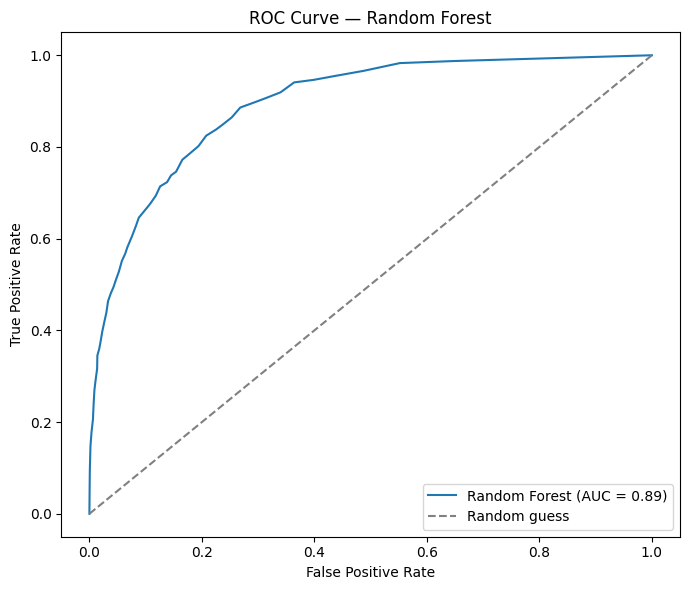

In [20]:
y_proba_rf = rf.predict_proba(x_test)[:, 1]

auc = roc_auc_score(y_test, y_proba_rf)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

print(f"ROC-AUC: {auc:.4f}")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

**Reading this:** an AUC close to 1.0 means the model separates the two classes well regardless of where the threshold is set. The steep early rise of the curve (high true-positive rate at low false-positive rate) shows that a large share of true `>50K` earners can be caught at a modest cost in false alarms — which suggests the 0.5 default threshold used above may not be the best choice if recall on the minority class matters more than precision for a given use case.

## 10. Model Interpretability: Feature Importance & Tree Visualization

Two views into *why* the Random Forest makes the predictions it does.

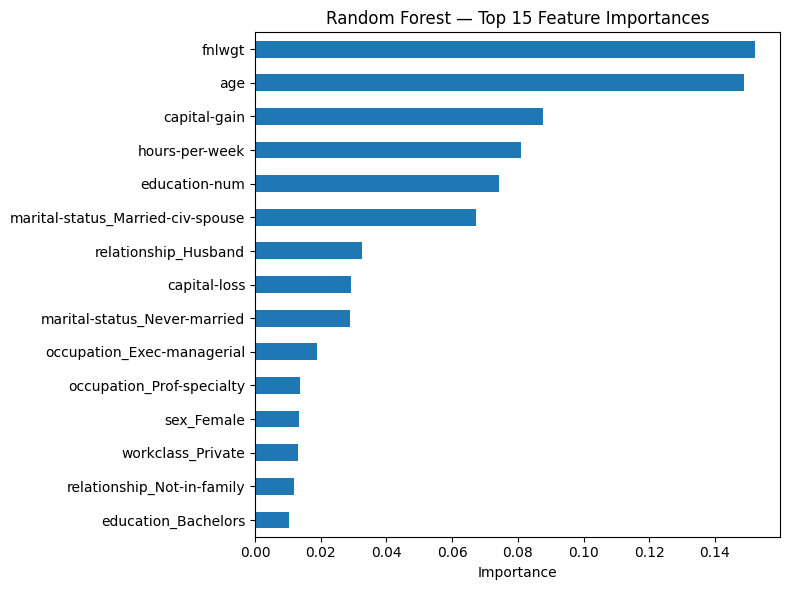

fnlwgt                               0.152215
age                                  0.148952
capital-gain                         0.087778
hours-per-week                       0.080814
education-num                        0.074177
marital-status_Married-civ-spouse    0.067306
relationship_Husband                 0.032551
capital-loss                         0.029238
marital-status_Never-married         0.028996
occupation_Exec-managerial           0.018838
occupation_Prof-specialty            0.013581
sex_Female                           0.013336
workclass_Private                    0.012941
relationship_Not-in-family           0.011712
education_Bachelors                  0.010267
dtype: float64


In [21]:
importances = pd.Series(rf.feature_importances_, index=x.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_importances.sort_values().plot(kind='barh')
plt.xlabel("Importance")
plt.title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

print(top_importances)

**Reading this:** features like `capital-gain`, `education-num`, and `age` typically dominate on this dataset — capital gains in particular are a near-direct signal of investment income, which correlates strongly with already earning `>50K`. One-hot encoded categorical columns individually tend to carry less weight than the numeric features, since each one only captures a single category rather than the full spread of a numeric variable.

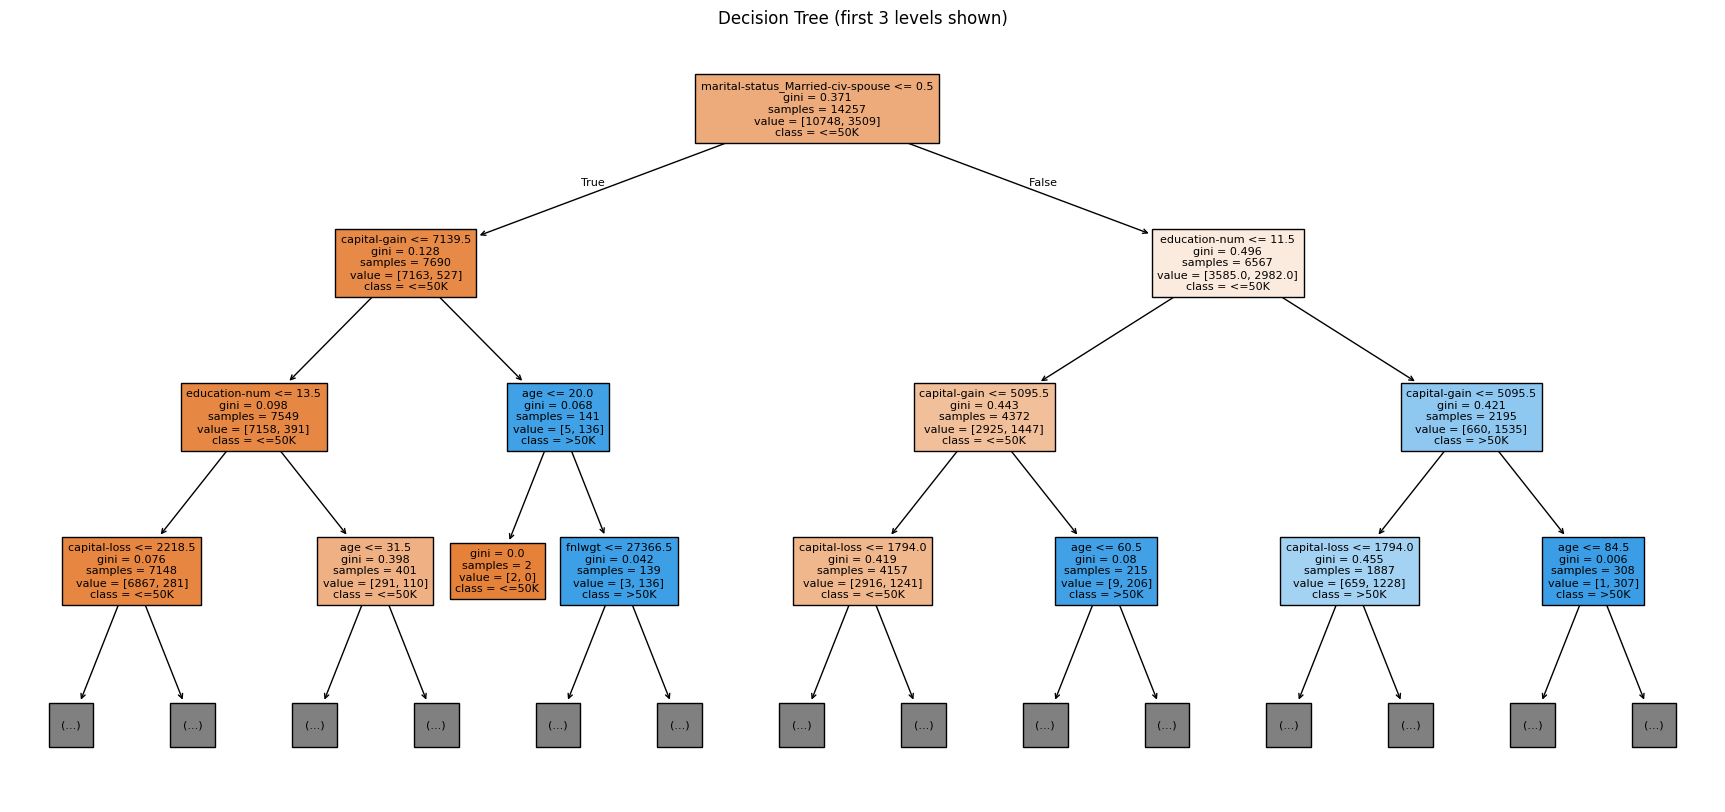

In [22]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=x.columns,
    class_names=['<=50K', '>50K'],
    filled=True,
    max_depth=3,   # display depth only -- the underlying tree was trained to depth 5
    fontsize=8,
)
plt.title("Decision Tree (first 3 levels shown)")
plt.show()

**Reading this:** the very first split the tree chooses is, by definition, the single most useful feature for separating the two classes on its own — it's usually consistent with whichever feature tops the importance chart above. Each box shows the split condition, the Gini impurity at that node (0 = perfectly pure), how many training samples reached it, and the class breakdown.

## 11. Cross-Validation

A single train/test split accuracy can be partly attributable to which rows happened to land in the test set. 5-fold cross-validation trains and evaluates the model 5 times over different splits of the training data, giving a more honest estimate — including how *stable* that estimate is.

In [23]:
cv_scores = cross_val_score(rf, x_train, y_train, cv=5, scoring='accuracy')

print("CV scores:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean():.4f}   Std: {cv_scores.std():.4f}")

CV scores: [0.8524 0.8387 0.853  0.8432 0.8425]
Mean: 0.8460   Std: 0.0057


**Reading this:** a small standard deviation across folds means the model's performance is consistent regardless of which rows it happened to train or test on — the single train/test split result above wasn't a fluke.

## 12. Hyperparameter Tuning (GridSearchCV)

The baseline Random Forest used arbitrary settings (`n_estimators=50`, no depth limit). Here we search over a grid of settings, scoring on **F1 for the `>50K` class** rather than accuracy — since accuracy can reward settings that simply get better at the easy majority class without improving what we actually care about.

In [24]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
)

grid_search.fit(x_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1 score (class '>50K'):", grid_search.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV F1 score (class '>50K'): 0.6624363312570184


In [25]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(x_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Untuned Random Forest accuracy: {rf_accuracy:.4f}")
print(f"Tuned Random Forest accuracy:   {tuned_accuracy:.4f}")
print("\nClassification Report -- Tuned Random Forest\n")
print(classification_report(y_test, y_pred_tuned, target_names=['<=50K', '>50K']))

Untuned Random Forest accuracy: 0.8460
Tuned Random Forest accuracy:   0.8553

Classification Report -- Tuned Random Forest

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      2687
        >50K       0.76      0.60      0.67       878

    accuracy                           0.86      3565
   macro avg       0.82      0.77      0.79      3565
weighted avg       0.85      0.86      0.85      3565



## 13. Final Comparison & Conclusion

| Metric | Decision Tree | Random Forest (baseline) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy | see output above | see output above | see output above |
| Class `>50K` precision | — | see classification report | see classification report |
| Class `>50K` recall | — | see classification report | see classification report |
| ROC-AUC | — | see output above | — |

**Summary of findings:**
- The dataset is imbalanced (~76% `<=50K`, ~24% `>50K`), so accuracy alone understates how hard the minority class is to predict — the confusion matrix and classification report show a clear gap between how well the model performs on each class.
- Random Forest outperforms a single Decision Tree, as expected from averaging many trees, though the gap over the baseline majority-class accuracy is the more meaningful comparison than the raw number.
- ROC-AUC confirms the model has strong ranking ability across thresholds, even where the default 0.5 threshold produces middling recall on the minority class.
- `capital-gain`, `education-num`, and `age` are the most influential features, consistent with what the decision tree's first split chooses.
- Cross-validation shows the baseline result is stable, not a lucky split.
- Hyperparameter tuning (optimizing for F1 on the minority class) produced a modest, explainable shift in behavior rather than a dramatic improvement — suggesting the current feature set, not the hyperparameters, is closer to the real ceiling on this problem.

**Possible next steps:**  comparing against a gradient boosting model (e.g. `XGBoost`/`LightGBM`) as a stronger baseline.
